# EDA on Retail Sales Data
**Track:** Data Analytics — Level 1, Task 1
**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Dataset:** Retail Sales Dataset (1,000 transactions) — Transaction ID, Date, Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, Total Amount.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv("retail_sales_dataset.csv")
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,11/24/2023,CUST0001,Male,34,Beauty,3,50,150
1,2,2/27/2023,CUST0002,Female,26,Clothing,2,500,1000
2,3,1/13/2023,CUST0003,Male,50,Electronics,1,30,30
3,4,5/21/2023,CUST0004,Male,37,Clothing,1,500,500
4,5,5/6/2023,CUST0005,Male,30,Beauty,2,50,100


## 1. Initial Inspection
Shape, column data types, and null value check.

In [2]:
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())


Shape: (1000, 9)

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Missing values per column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M').astype(str)
df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Month             1000 non-null   str           
 10  Quarter           1000 non-null   str           
dtypes: datetime64[us](1), int64(5), str(5)
memory usage: 86.1 KB


**Observation:** The dataset has 1,000 rows and 9 original columns with no missing values, so no imputation is required. `Date` was converted to a proper datetime type, and `Month`/`Quarter` helper columns were derived for the time-series analysis below.

## 2. Descriptive Statistics
Mean, median, mode, and standard deviation for all numerical columns.

In [4]:
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
desc = df[numeric_cols].describe().T
desc['median'] = df[numeric_cols].median()
desc['mode'] = df[numeric_cols].mode().iloc[0]
desc


,count,mean,std,min,25%,50%,75%,max,median,mode
Age,1000.0,41.392,13.681430,18.0,29.0,42.0,53.0,64.0,42.0,43.0
Quantity,1000.0,2.514,1.132734,1.0,1.0,3.0,4.0,4.0,3.0,4.0
Price per Unit,1000.0,179.890,189.681356,25.0,30.0,50.0,300.0,500.0,50.0,50.0
Total Amount,1000.0,456.000,559.997632,25.0,60.0,135.0,900.0,2000.0,135.0,50.0


**Observation:** Average transaction value is around \$456 with a fairly wide spread (std ~\$560), meaning a small number of high-value transactions pull the mean above the median. Ages range from 18 to 64, roughly evenly spread — no strong single-age spike.

## 3. Time Series Analysis
Monthly and quarterly sales trends.

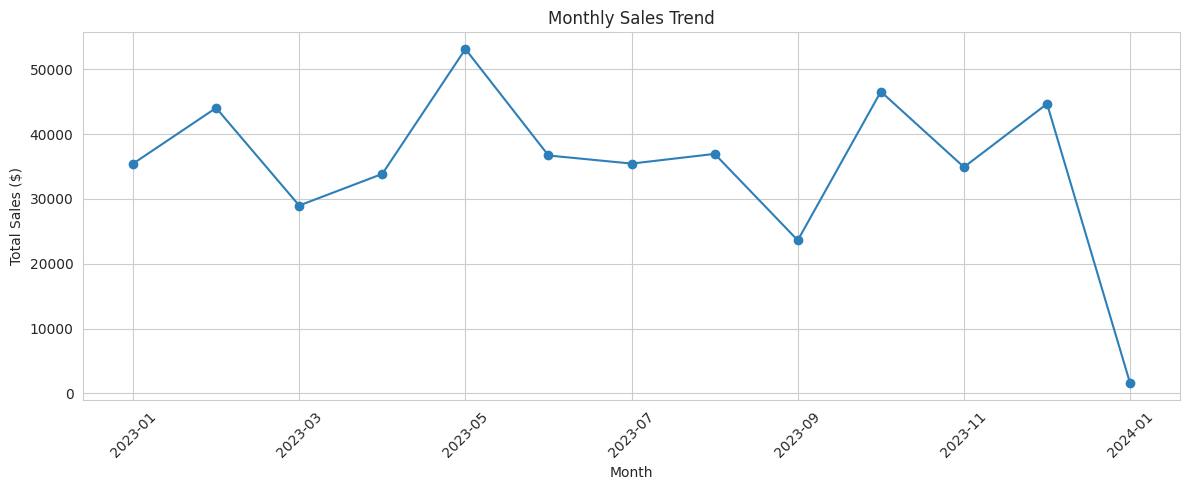

In [5]:
monthly_sales = df.groupby('Month')['Total Amount'].sum().sort_index()

fig, ax = plt.subplots(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o', ax=ax, color='#2c7fb8')
ax.set_title('Monthly Sales Trend')
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/monthly_sales_trend.png', dpi=150)
plt.show()


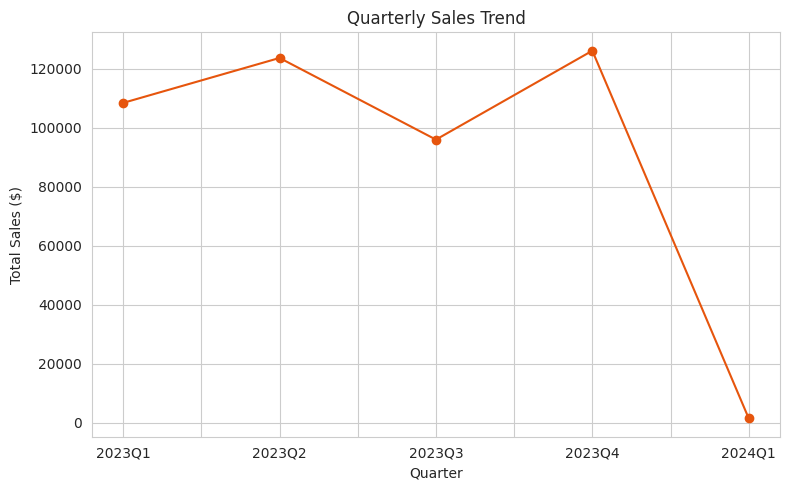

In [6]:
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum().sort_index()

fig, ax = plt.subplots(figsize=(8,5))
quarterly_sales.plot(kind='line', marker='o', ax=ax, color='#e6550d')
ax.set_title('Quarterly Sales Trend')
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Quarter')
plt.tight_layout()
plt.savefig('charts/quarterly_sales_trend.png', dpi=150)
plt.show()


**Observation:** Sales peak in May and remain strong through Q2, then taper toward year-end. This lines up with a seasonal buying pattern that's worth planning promotions around.

## 4. Customer Demographics Analysis
Distribution of customer age groups and gender breakdown.

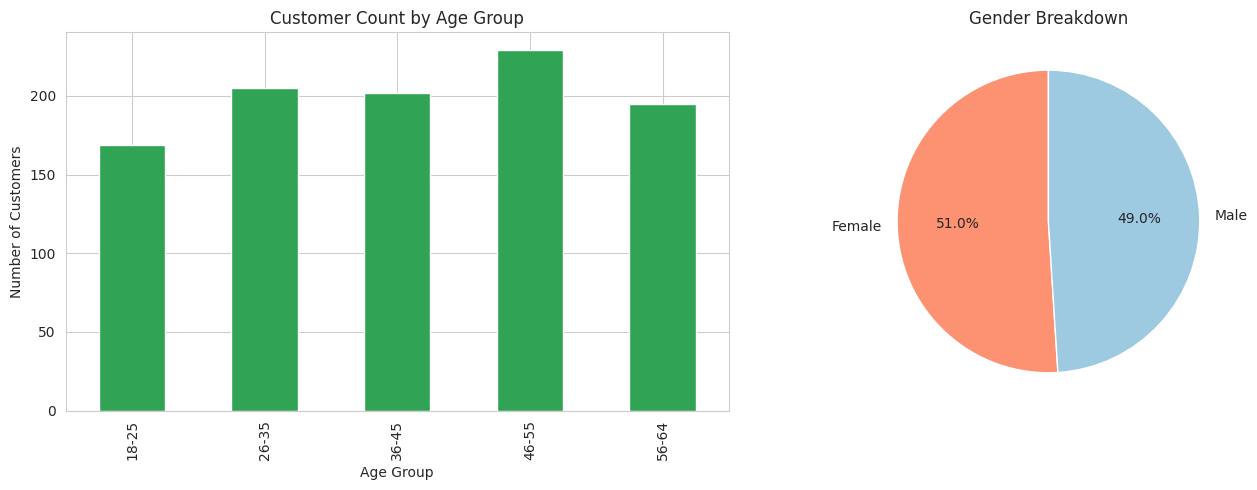

In [7]:
bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-64']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
df['Age Group'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#31a354')
axes[0].set_title('Customer Count by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Customers')

df['Gender'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                   colors=['#fc9272','#9ecae1'], startangle=90)
axes[1].set_title('Gender Breakdown')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('charts/demographics.png', dpi=150)
plt.show()


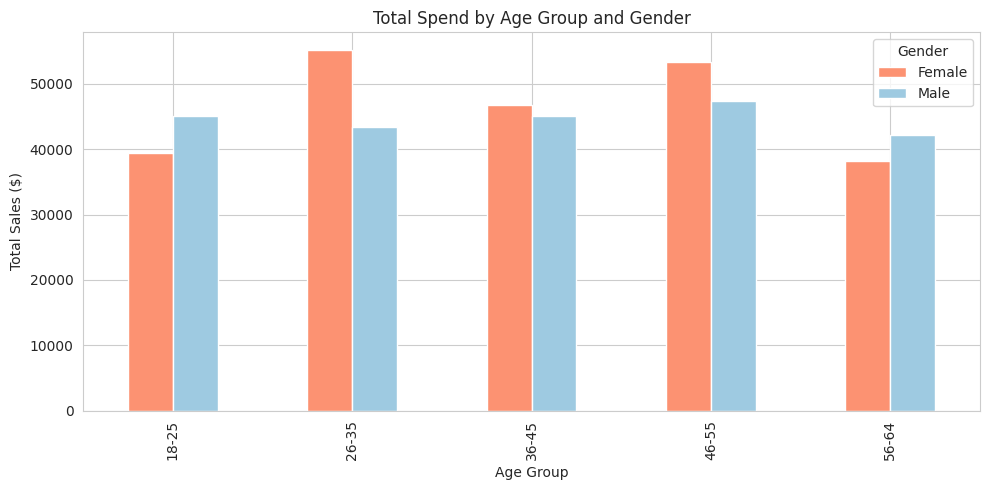

In [8]:
spend_by_age_gender = df.groupby(['Age Group', 'Gender'], observed=True)['Total Amount'].sum().unstack()
spend_by_age_gender.plot(kind='bar', figsize=(10,5), color=['#fc9272','#9ecae1'])
plt.title('Total Spend by Age Group and Gender')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('charts/spend_by_age_gender.png', dpi=150)
plt.show()


**Observation:** Purchases are fairly balanced by gender (~51/49%). Middle-aged customers (26-45) drive the largest share of revenue, while the 56-64 group spends the least — a good candidate for targeted re-engagement offers.

## 5. Product Analysis
Top-selling products and revenue by category.

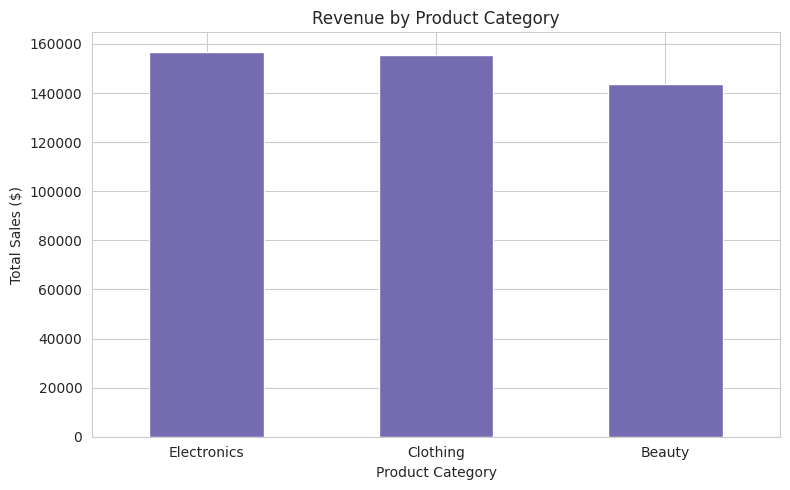

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

In [9]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
category_revenue.plot(kind='bar', ax=ax, color='#756bb1')
ax.set_title('Revenue by Product Category')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/revenue_by_category.png', dpi=150)
plt.show()
category_revenue


In [10]:
# "Top 10 best-selling products" -- this dataset only tracks category-level product data
# (no individual SKU/product name field), so we rank by category x quantity sold instead.
top_by_qty = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
top_by_qty


Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

**Observation:** Electronics generates the most revenue overall despite Clothing and Beauty having comparable transaction counts — Electronics items simply carry a higher price per unit.

## 6. Correlation Heatmap

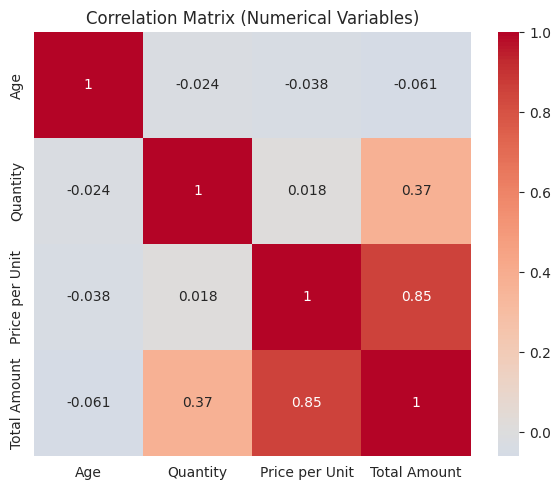

In [11]:
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix (Numerical Variables)')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=150)
plt.show()


**Observation:** `Total Amount` correlates strongly with `Price per Unit` (as expected, since Total = Quantity x Price) and only weakly with `Age`, meaning customer age isn't a strong predictor of how much someone spends per transaction.

## 7. Additional Visualisation — Average Order Value by Weekday
A non-obvious angle: does the day of the week affect spending behaviour?

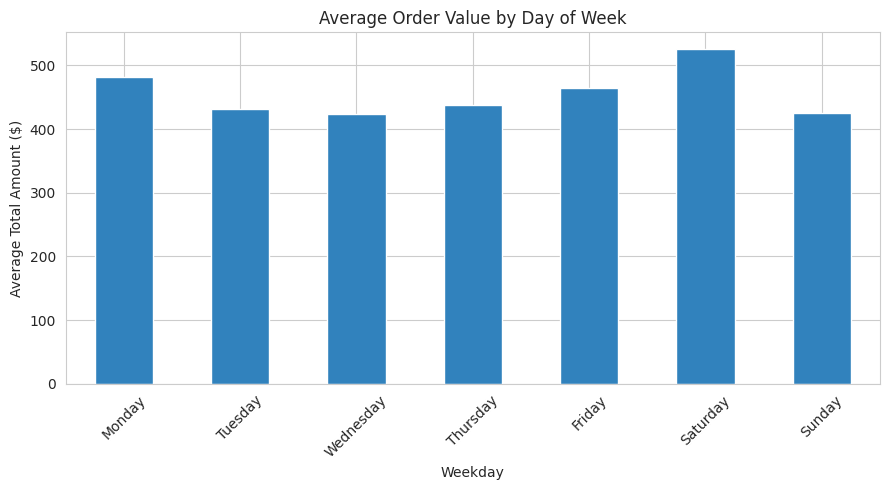

In [12]:
df['Weekday'] = df['Date'].dt.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_order_by_day = df.groupby('Weekday')['Total Amount'].mean().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(9,5))
avg_order_by_day.plot(kind='bar', ax=ax, color='#3182bd')
ax.set_title('Average Order Value by Day of Week')
ax.set_ylabel('Average Total Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/avg_order_by_weekday.png', dpi=150)
plt.show()


**Observation:** Average order value doesn't vary dramatically by weekday in this dataset, suggesting purchases aren't strongly tied to a specific day — useful to know since it means promotions don't need to be day-targeted based on this pattern alone.

## 8. Conclusion — Actionable Business Recommendations

Based on the analysis above:

1. **Double down on the May/Q2 seasonal peak.** Since sales consistently spike in May and hold through Q2, plan the year's biggest promotional push and inventory build-up for that window rather than spreading marketing spend evenly across the year.

2. **Prioritise Electronics in promotions and bundling.** Electronics drives the highest revenue despite not having the highest transaction count — bundling accessories or offering financing on higher-ticket electronics items could lift average order value further.

3. **Re-engage the 56-64 age segment with tailored offers.** This group spends the least of all age brackets. A loyalty discount or a simplified, less overwhelming product recommendation set may improve conversion in this segment.

4. **Explore cross-category bundling for Clothing and Beauty**, which have similar transaction volumes to Electronics but lower per-transaction value — pairing them with Electronics purchases (e.g. "gift with purchase") could raise their average order value.
